# Notebook 7: Statlog Australian Credit Approval (UCI)
**Fuente:** https://archive.ics.uci.edu/ml/datasets/statlog+(australian+credit+approval)

Dataset de aprobación de crédito australiano del proyecto Statlog. Variables anonimizadas con mezcla de atributos categóricos y continuos.

## Introducción
El **Australian Credit Dataset** (Statlog) contiene 690 instancias y 14 atributos de entrada. La variable objetivo (`A15`) es binaria: 0 = rechazado, 1 = aprobado. Los atributos han sido completamente anonimizados por razones de confidencialidad. Se trata de un problema de **clasificación binaria**. A diferencia del dataset UCI Credit Approval (crx.data), este no contiene valores faltantes.

## Carga del Dataset

In [2]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    EXPORT_PATH = '/content/drive/MyDrive/datasets/australian_credit/'
else:
    EXPORT_PATH = './australian_credit_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat'

COLUMNS = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15']

df = pd.read_csv(URL, header=None, names=COLUMNS, sep=' ')
print(f'Dataset cargado: {df.shape}')
df.head()

Mounted at /content/drive
Dataset cargado: (690, 15)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


## Identificación del Tipo de Problema

In [3]:
TARGET = 'A15'
print(f'Variable objetivo: {TARGET}')
print(f'Valores únicos: {df[TARGET].unique()}')
print(f'Distribución:\n{df[TARGET].value_counts()}')
print('\n→ Tipo de problema: CLASIFICACIÓN BINARIA (0=rechazado, 1=aprobado)')

Variable objetivo: A15
Valores únicos: [0 1]
Distribución:
A15
0    383
1    307
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN BINARIA (0=rechazado, 1=aprobado)


## Análisis Exploratorio (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Info del dataset:')
df.info()
print('\nEstadísticas descriptivas:')
display(df.describe())

Info del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    int64  
 1   A2      690 non-null    float64
 2   A3      690 non-null    float64
 3   A4      690 non-null    int64  
 4   A5      690 non-null    int64  
 5   A6      690 non-null    int64  
 6   A7      690 non-null    float64
 7   A8      690 non-null    int64  
 8   A9      690 non-null    int64  
 9   A10     690 non-null    int64  
 10  A11     690 non-null    int64  
 11  A12     690 non-null    int64  
 12  A13     690 non-null    int64  
 13  A14     690 non-null    int64  
 14  A15     690 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 81.0 KB

Estadísticas descriptivas:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000,690.000000
mean,0.678261,31.568203,4.758725,1.766667,7.372464,4.692754,2.223406,0.523188,0.427536,2.40000,0.457971,1.928986,184.014493,1018.385507,0.444928
std,0.467482,11.853273,4.978163,0.430063,3.683265,1.992316,3.346513,0.499824,0.495080,4.86294,0.498592,0.298813,172.159274,5210.102598,0.497318
min,0.000000,13.750000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,0.000000,22.670000,1.000000,2.000000,4.000000,4.000000,0.165000,0.000000,0.000000,0.00000,0.000000,2.000000,80.000000,1.000000,0.000000
50%,1.000000,28.625000,2.750000,2.000000,8.000000,4.000000,1.000000,1.000000,0.000000,0.00000,0.000000,2.000000,160.000000,6.000000,0.000000
75%,1.000000,37.707500,7.207500,2.000000,10.000000,5.000000,2.625000,1.000000,1.000000,3.00000,1.000000,2.000000,272.000000,396.500000,1.000000
max,1.000000,80.250000,28.000000,3.000000,14.000000,9.000000,28.500000,1.000000,1.000000,67.00000,1.000000,3.000000,2000.000000,100001.000000,1.000000


In [6]:
print(f'Valores nulos: {df.isnull().sum().sum()}')
print(f'Duplicados: {df.duplicated().sum()}')

Valores nulos: 0
Duplicados: 0


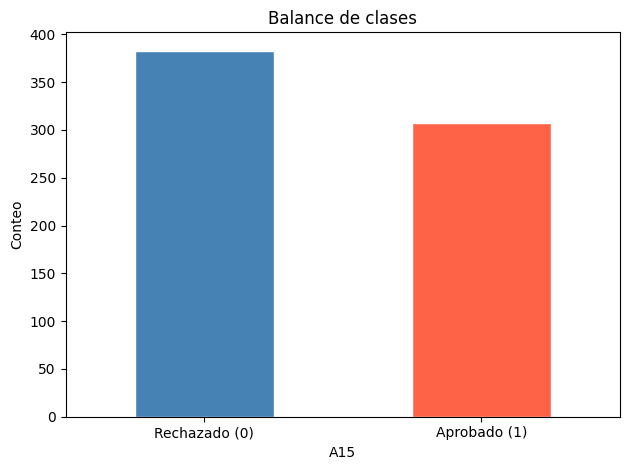

In [7]:
# Balance de clases
df[TARGET].value_counts().plot(kind='bar', color=['steelblue','tomato'], edgecolor='white')
plt.title('Balance de clases')
plt.xticks([0,1], ['Rechazado (0)', 'Aprobado (1)'], rotation=0)
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

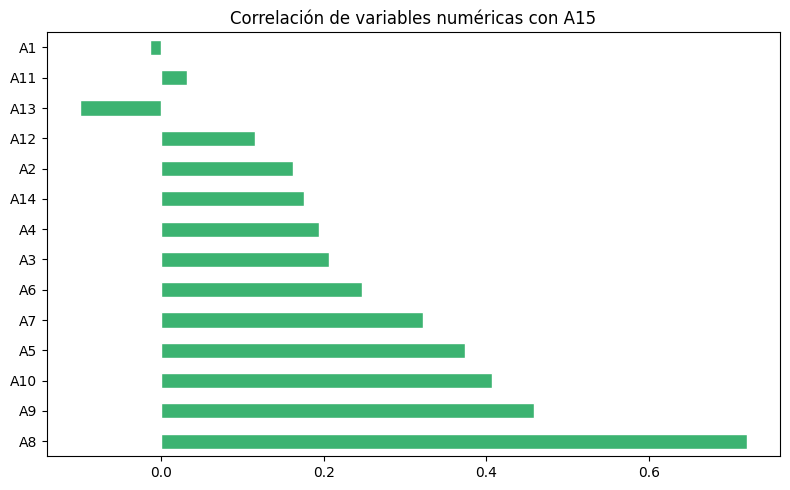

In [9]:
# Correlación con target
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df[num_cols].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
corr_with_target.plot(kind='barh', color='mediumseagreen', edgecolor='white', figsize=(8,5))
plt.title(f'Correlación de variables numéricas con {TARGET}')
plt.tight_layout()
plt.show()

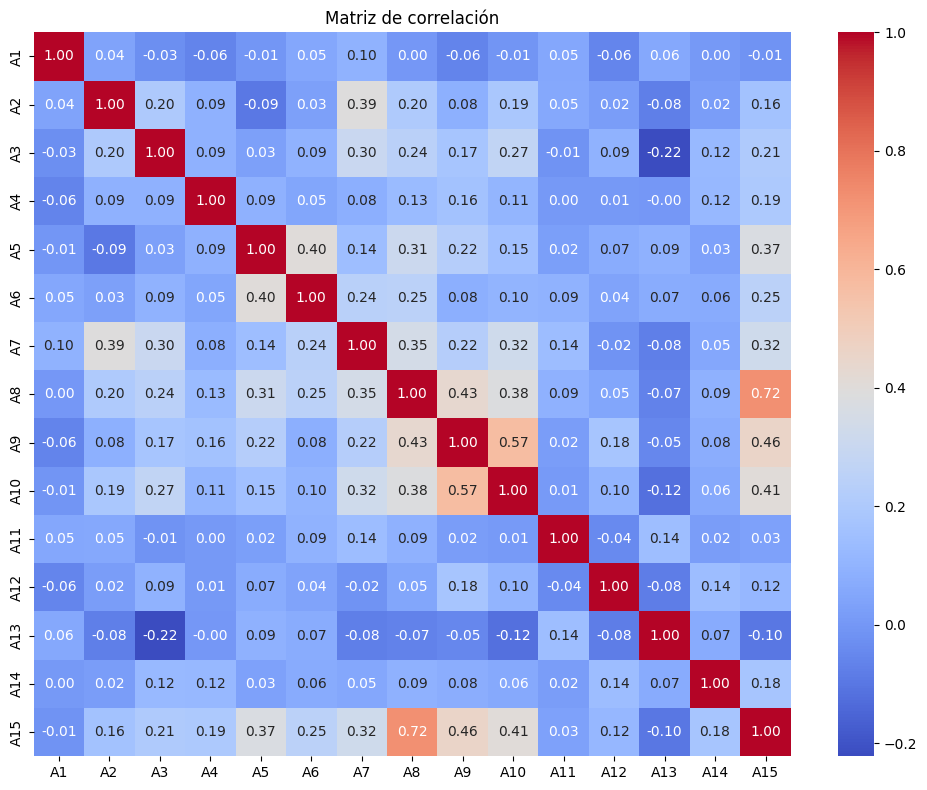

In [10]:
# Heatmap de correlación
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

## Limpieza y Preparación
Este dataset no contiene valores nulos, pero verificamos y tratamos duplicados.

In [11]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()

# Identificar columnas categóricas (valores enteros con pocos valores únicos)
cat_candidate_cols = [c for c in df_clean.columns if c != TARGET and df_clean[c].nunique() <= 10]
num_candidate_cols = [c for c in df_clean.columns if c != TARGET and c not in cat_candidate_cols]

print(f'Columnas tratadas como categóricas: {cat_candidate_cols}')
print(f'Columnas tratadas como numéricas: {num_candidate_cols}')
print(f'Shape final: {df_clean.shape}')

Columnas tratadas como categóricas: ['A1', 'A4', 'A6', 'A8', 'A9', 'A11', 'A12']
Columnas tratadas como numéricas: ['A2', 'A3', 'A5', 'A7', 'A10', 'A13', 'A14']
Shape final: (690, 15)


In [12]:
# Tratamiento de outliers en columnas numéricas continuas
for col in num_candidate_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR  # umbral amplio para no perder datos
    upper = Q3 + 3 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    if outliers > 0:
        df_clean[col] = df_clean[col].clip(lower, upper)
        print(f'  {col}: {outliers} outliers suavizados con clip')

print(f'Shape tras tratamiento de outliers: {df_clean.shape}')

  A3: 2 outliers suavizados con clip
  A7: 26 outliers suavizados con clip
  A10: 24 outliers suavizados con clip
  A13: 4 outliers suavizados con clip
  A14: 76 outliers suavizados con clip
Shape tras tratamiento de outliers: (690, 15)


##  Transformación y Preprocesamiento

In [13]:
from sklearn.preprocessing import StandardScaler

df_processed = df_clean.copy()

# Escalar solo las columnas numéricas continuas
scaler = StandardScaler()
df_processed[num_candidate_cols] = scaler.fit_transform(df_processed[num_candidate_cols])

# Las categóricas ya son enteros (0/1/2...) — pueden usarse directo o con get_dummies
df_processed = pd.get_dummies(df_processed, columns=cat_candidate_cols, drop_first=True)

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Shape preprocesado: (690, 23)


,A2,A3,A5,A7,A10,A13,A14,A15,A1_1,A4_2,...,A6_4,A6_5,A6_7,A6_8,A6_9,A8_1,A9_1,A11_1,A12_2,A12_3
0,-0.801052,1.352560,-0.916282,-0.173257,-0.605477,-0.523744,1.655862,0,True,True,...,True,False,False,False,False,False,False,True,True,False
1,-0.751240,0.452891,0.170499,-0.712655,-0.605477,-0.138570,-0.597755,0,False,True,...,True,False,False,False,False,False,False,False,True,False
2,-0.167856,-0.606136,-0.916282,-0.300509,-0.605477,0.631779,-0.597755,0,False,False,...,True,False,False,False,False,False,False,True,True,False
3,-0.835667,1.360629,-0.644587,-0.775331,2.482943,-1.165702,-0.597755,1,False,False,...,False,False,False,False,False,True,True,True,True,False
4,-0.962306,0.688903,-0.372892,-0.030810,2.763709,-0.780527,-0.303967,1,True,True,...,True,False,False,False,False,True,True,False,True,False


##  División Train/Test (80/20, stratify)

In [14]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Proporción aprobados - Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (552, 23)  |  Test: (138, 23)
Proporción aprobados - Train: 0.446  |  Test: 0.442


##  Exportación de train.csv y test.csv

In [ ]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')